In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv("../data/customer_churn_data.csv")

# Preview the first 5 rows
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TotalCharges,TechSupport,Churn
0,1,49,Male,4,88.35,Month-to-Month,Fiber Optic,353.40,Yes,Yes
1,2,43,Male,0,36.67,Month-to-Month,Fiber Optic,0.00,Yes,Yes
2,3,51,Female,2,63.79,Month-to-Month,Fiber Optic,127.58,No,Yes
3,4,60,Female,8,102.34,One-Year,DSL,818.72,Yes,Yes
4,5,42,Male,32,69.01,Month-to-Month,NaN,2208.32,No,Yes


In [4]:
# 1. How big is the dataset?
print("Shape:", df.shape)

# 2. Column data types
print("\nData Types:")
print(df.dtypes)

# 3. Any missing values?
print("\nMissing Values:")
print(df.isnull().sum())

# 4. What % of customers churned?
print("\nChurn Distribution:")
print(df['Churn'].value_counts())
print(df['Churn'].value_counts(normalize=True) * 100)

Shape: (1000, 10)

Data Types:
CustomerID           int64
Age                  int64
Gender              object
Tenure               int64
MonthlyCharges     float64
ContractType        object
InternetService     object
TotalCharges       float64
TechSupport         object
Churn               object
dtype: object

Missing Values:
CustomerID           0
Age                  0
Gender               0
Tenure               0
MonthlyCharges       0
ContractType         0
InternetService    297
TotalCharges         0
TechSupport          0
Churn                0
dtype: int64

Churn Distribution:
Churn
Yes    883
No     117
Name: count, dtype: int64
Churn
Yes    88.3
No     11.7
Name: proportion, dtype: float64


FileNotFoundError: [Errno 2] No such file or directory: '../reports/figures/eda_overview.png'

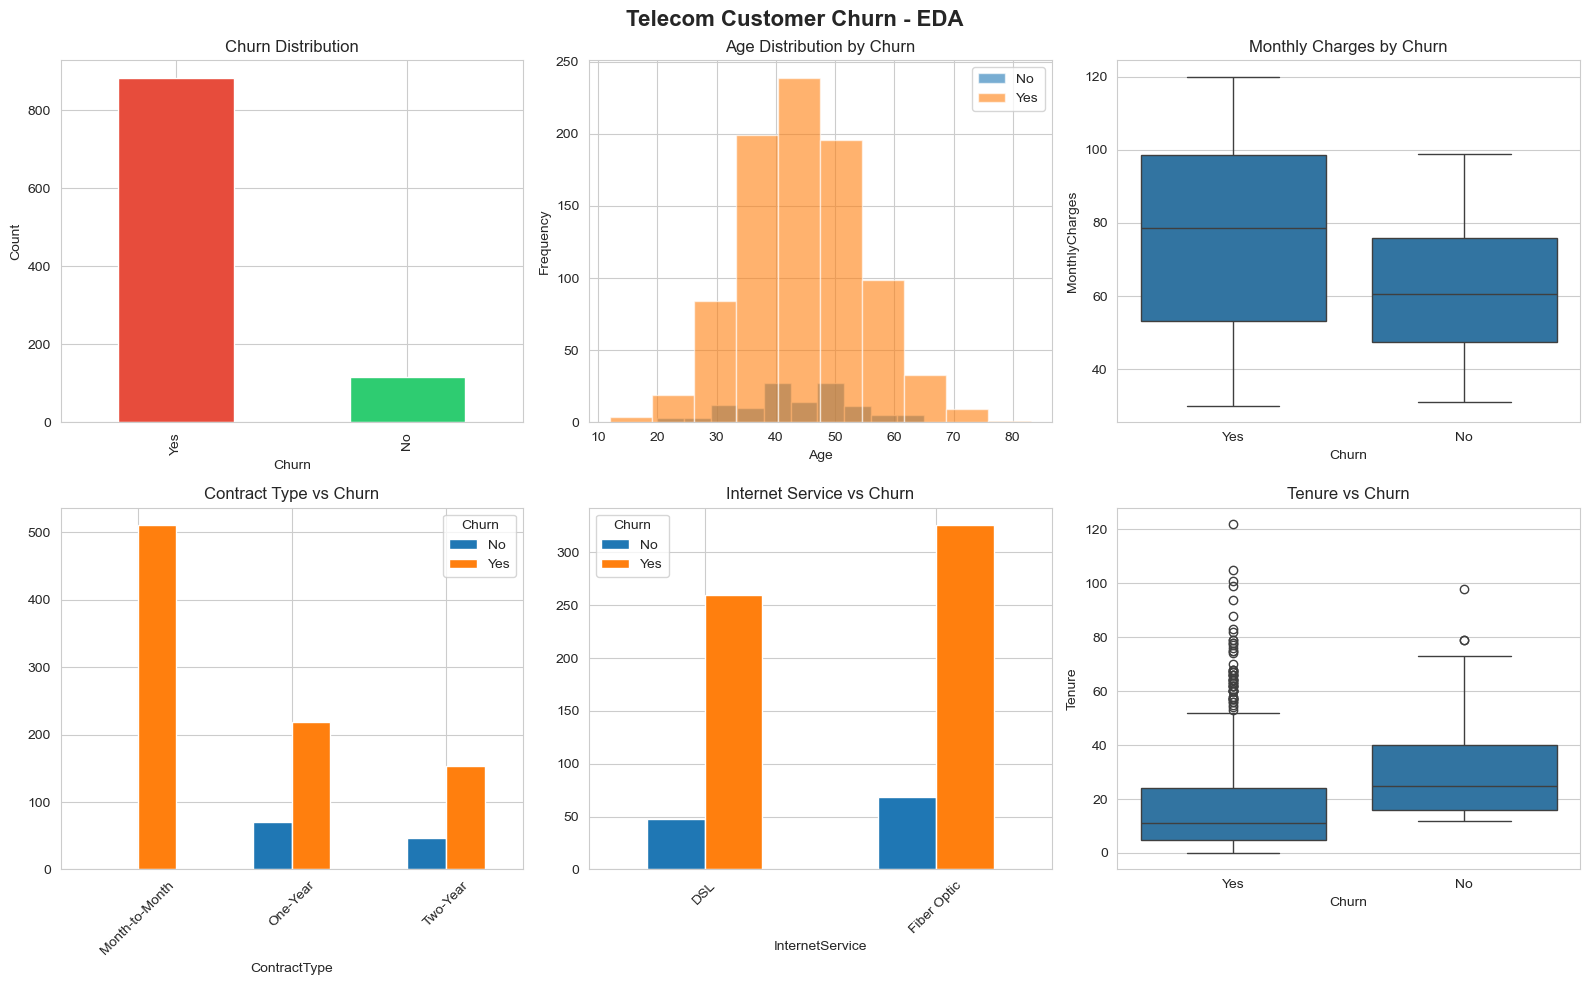

In [5]:
# Set visual style
sns.set_style("whitegrid")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Telecom Customer Churn - EDA", fontsize=16, fontweight='bold')

# 1. Churn Distribution
df['Churn'].value_counts().plot(kind='bar', ax=axes[0,0], color=['#e74c3c','#2ecc71'])
axes[0,0].set_title("Churn Distribution")
axes[0,0].set_xlabel("Churn")
axes[0,0].set_ylabel("Count")

# 2. Age Distribution by Churn
df.groupby('Churn')['Age'].plot(kind='hist', alpha=0.6, ax=axes[0,1], legend=True)
axes[0,1].set_title("Age Distribution by Churn")
axes[0,1].set_xlabel("Age")

# 3. Monthly Charges by Churn
sns.boxplot(x='Churn', y='MonthlyCharges', data=df, ax=axes[0,2])
axes[0,2].set_title("Monthly Charges by Churn")

# 4. Contract Type vs Churn
pd.crosstab(df['ContractType'], df['Churn']).plot(kind='bar', ax=axes[1,0])
axes[1,0].set_title("Contract Type vs Churn")
axes[1,0].tick_params(axis='x', rotation=45)

# 5. Internet Service vs Churn
pd.crosstab(df['InternetService'], df['Churn']).plot(kind='bar', ax=axes[1,1])
axes[1,1].set_title("Internet Service vs Churn")
axes[1,1].tick_params(axis='x', rotation=45)

# 6. Tenure Distribution by Churn
sns.boxplot(x='Churn', y='Tenure', data=df, ax=axes[1,2])
axes[1,2].set_title("Tenure vs Churn")

plt.tight_layout()
plt.savefig("../reports/figures/eda_overview.png", dpi=150)
plt.show()
print("✅ Charts saved!")

In [6]:
import os

# Create the figures folder if it doesn't exist
os.makedirs("../reports/figures", exist_ok=True)

# Now save the figure
plt.savefig("../reports/figures/eda_overview.png", dpi=150)
print("✅ Charts saved successfully!")

✅ Charts saved successfully!


<Figure size 640x480 with 0 Axes>

In [2]:
# ============================================
# IMPORTS + LOAD DATA + PREPROCESSING
# ============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

# Load the dataset
df = pd.read_csv("../data/customer_churn_data.csv")

# Step 1 - Drop CustomerID
df = df.drop(columns=['CustomerID'])

# Step 2 - Fill missing InternetService values
df['InternetService'] = df['InternetService'].fillna(df['InternetService'].mode()[0])

# Step 3 - Convert text columns to numbers
le = LabelEncoder()
text_columns = ['Gender', 'ContractType', 'InternetService', 'TechSupport', 'Churn']

for col in text_columns:
    df[col] = le.fit_transform(df[col])

# Step 4 - Confirm everything looks good
print("✅ Missing values after fix:")
print(df.isnull().sum())
print("\n✅ First 5 rows after preprocessing:")
print(df.head())

✅ Missing values after fix:
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TotalCharges       0
TechSupport        0
Churn              0
dtype: int64

✅ First 5 rows after preprocessing:
   Age  Gender  Tenure  MonthlyCharges  ContractType  InternetService  \
0   49       1       4           88.35             0                1   
1   43       1       0           36.67             0                1   
2   51       0       2           63.79             0                1   
3   60       0       8          102.34             1                0   
4   42       1      32           69.01             0                1   

   TotalCharges  TechSupport  Churn  
0        353.40            1      1  
1          0.00            1      1  
2        127.58            0      1  
3        818.72            1      1  
4       2208.32            0      1  


In [3]:
# ============================================
# PHASE 4 - BUILD PREDICTIVE MODELS
# ============================================
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score
from imblearn.over_sampling import SMOTE

# Step 1 - Separate features (X) from target (y)
X = df.drop(columns=['Churn'])  # Everything except Churn
y = df['Churn']                 # Only Churn column

print("Features shape:", X.shape)
print("Target shape:", y.shape)

# Step 2 - Fix class imbalance with SMOTE
smote = SMOTE(random_state=42)
X_balanced, y_balanced = smote.fit_resample(X, y)
print("\n✅ After SMOTE balancing:")
print(pd.Series(y_balanced).value_counts())

# Step 3 - Split into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X_balanced, y_balanced, test_size=0.2, random_state=42
)
print("\n✅ Training set size:", X_train.shape)
print("✅ Testing set size:", X_test.shape)

# Step 4 - Train 3 models
print("\n🤖 Training models...")

# Model 1 - Logistic Regression
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train, y_train)
print("✅ Logistic Regression trained!")

# Model 2 - Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
print("✅ Random Forest trained!")

# Model 3 - XGBoost
xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
print("✅ XGBoost trained!")

print("\n🎉 All 3 models trained successfully!")

Features shape: (1000, 8)
Target shape: (1000,)

✅ After SMOTE balancing:
Churn
1    883
0    883
Name: count, dtype: int64

✅ Training set size: (1412, 8)
✅ Testing set size: (354, 8)

🤖 Training models...
✅ Logistic Regression trained!
✅ Random Forest trained!
✅ XGBoost trained!

🎉 All 3 models trained successfully!



  Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.89      0.94      0.91       175
       Churn       0.93      0.88      0.91       179

    accuracy                           0.91       354
   macro avg       0.91      0.91      0.91       354
weighted avg       0.91      0.91      0.91       354


  Random Forest
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00       175
       Churn       1.00      1.00      1.00       179

    accuracy                           1.00       354
   macro avg       1.00      1.00      1.00       354
weighted avg       1.00      1.00      1.00       354


  XGBoost
              precision    recall  f1-score   support

    No Churn       1.00      1.00      1.00       175
       Churn       1.00      1.00      1.00       179

    accuracy                           1.00       354
   macro avg       1.00      1.00      1.00       354
weighted avg       1.00

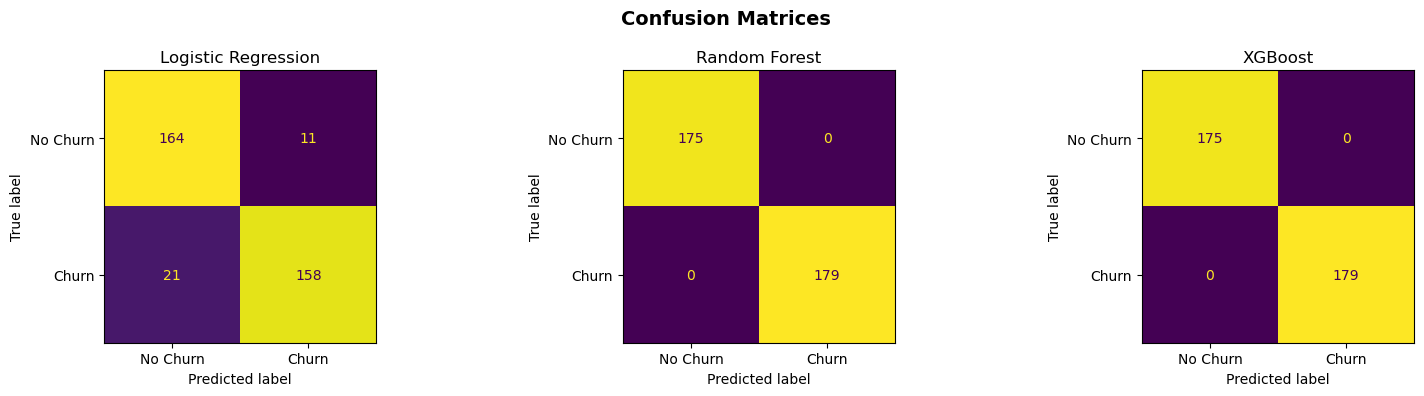

✅ Comparison charts saved!


In [4]:
# ============================================
# PHASE 5 - EVALUATE & COMPARE MODELS
# ============================================

from sklearn.metrics import (classification_report, roc_auc_score, 
                             confusion_matrix, ConfusionMatrixDisplay)

models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb
}

results = {}

for name, model in models.items():
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]
    
    auc = roc_auc_score(y_test, y_prob)
    report = classification_report(y_test, y_pred, output_dict=True)
    
    results[name] = {
        "AUC": round(auc, 4),
        "Accuracy": round(report['accuracy'], 4),
        "Precision": round(report['1']['precision'], 4),
        "Recall": round(report['1']['recall'], 4),
        "F1-Score": round(report['1']['f1-score'], 4)
    }
    
    print(f"\n{'='*45}")
    print(f"  {name}")
    print(f"{'='*45}")
    print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

# Summary comparison table
print("\n📊 MODEL COMPARISON SUMMARY:")
print("-" * 65)
print(f"{'Model':<25} {'Accuracy':>8} {'AUC':>8} {'F1-Score':>8} {'Recall':>8}")
print("-" * 65)
for name, metrics in results.items():
    print(f"{name:<25} {metrics['Accuracy']:>8} {metrics['AUC']:>8} {metrics['F1-Score']:>8} {metrics['Recall']:>8}")
print("-" * 65)

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Confusion Matrices", fontsize=14, fontweight='bold')

for ax, (name, model) in zip(axes, models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['No Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(name)

plt.tight_layout()
plt.savefig("../reports/figures/model_comparison.png", dpi=150)
plt.show()
print("✅ Comparison charts saved!")

C:\Users\LENOVO T570\AppData\Local\Temp\ipykernel_6088\4017502727.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=rf_importance, x='Importance', y='Feature', ax=axes[0], palette='Reds_r')
C:\Users\LENOVO T570\AppData\Local\Temp\ipykernel_6088\4017502727.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=xgb_importance, x='Importance', y='Feature', ax=axes[1], palette='Blues_r')


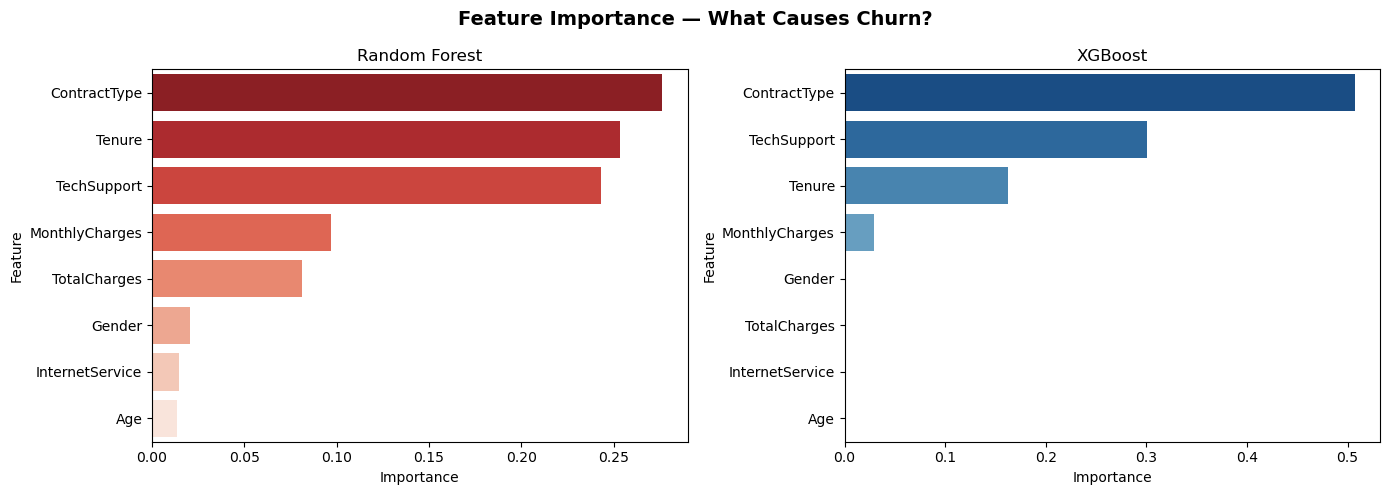


🔍 Top Churn Drivers (Random Forest):
        Feature  Importance
   ContractType    0.276246
         Tenure    0.253664
    TechSupport    0.243466
 MonthlyCharges    0.097081
   TotalCharges    0.081113
         Gender    0.020384
InternetService    0.014559
            Age    0.013488


In [5]:
# ============================================
# PHASE 6 - FEATURE IMPORTANCE
# ============================================

feature_names = X.columns.tolist()

# Get feature importance from Random Forest
rf_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': rf.feature_importances_
}).sort_values('Importance', ascending=False)

# Get feature importance from XGBoost
xgb_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb.feature_importances_
}).sort_values('Importance', ascending=False)

# Plot both
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Feature Importance — What Causes Churn?", fontsize=14, fontweight='bold')

sns.barplot(data=rf_importance, x='Importance', y='Feature', ax=axes[0], palette='Reds_r')
axes[0].set_title("Random Forest")

sns.barplot(data=xgb_importance, x='Importance', y='Feature', ax=axes[1], palette='Blues_r')
axes[1].set_title("XGBoost")

plt.tight_layout()
plt.savefig("../reports/figures/feature_importance.png", dpi=150)
plt.show()

print("\n🔍 Top Churn Drivers (Random Forest):")
print(rf_importance.to_string(index=False))

In [6]:
import joblib
import os

# Create models folder
os.makedirs("../models", exist_ok=True)

# Save all 3 models
joblib.dump(lr, "../models/logistic_regression.pkl")
joblib.dump(rf, "../models/random_forest.pkl")
joblib.dump(xgb, "../models/xgboost.pkl")

print("✅ All 3 models saved successfully!")
print("📁 Saved in: TELECOM_CHURN/models/")

✅ All 3 models saved successfully!
📁 Saved in: TELECOM_CHURN/models/
